In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

df = pd.read_csv('Ecommerce_Sales_Data_2024_2025.csv')
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [2]:
df.shape

(5000, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   str    
 2   Customer Name  5000 non-null   str    
 3   Region         5000 non-null   str    
 4   City           5000 non-null   str    
 5   Category       5000 non-null   str    
 6   Sub-Category   5000 non-null   str    
 7   Product Name   5000 non-null   str    
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   str    
dtypes: float64(2), int64(4), str(8)
memory usage: 547.0 KB


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[us]
 2   Customer Name  5000 non-null   str           
 3   Region         5000 non-null   str           
 4   City           5000 non-null   str           
 5   Category       5000 non-null   str           
 6   Sub-Category   5000 non-null   str           
 7   Product Name   5000 non-null   str           
 8   Quantity       5000 non-null   int64         
 9   Unit Price     5000 non-null   int64         
 10  Discount       5000 non-null   int64         
 11  Sales          5000 non-null   float64       
 12  Profit         5000 non-null   float64       
 13  Payment Mode   5000 non-null   str           
 14  Year           5000 non-null   int32         
dtypes: datetime64[us](1), float64(2)

In [5]:
df.describe()

,Order ID,Order Date,Quantity,Unit Price,Discount,Sales,Profit,Year
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,12500.500000,2024-09-30 18:58:27.840000,2.992600,39760.904600,10.051000,106733.204870,15941.746982,2024.25320
min,10001.000000,2023-10-04 00:00:00,1.000000,222.000000,0.000000,264.100000,19.120000,2023.00000
25%,11250.750000,2024-04-05 00:00:00,2.000000,20312.250000,5.000000,39766.537500,4892.295000,2024.00000
50%,12500.500000,2024-09-29 00:00:00,3.000000,39459.500000,10.000000,83080.325000,11108.525000,2024.00000
75%,13750.250000,2025-03-30 00:00:00,4.000000,59721.750000,15.000000,156968.587500,22467.987500,2025.00000
max,15000.000000,2025-10-03 00:00:00,5.000000,79998.000000,20.000000,398485.000000,89688.440000,2025.00000
std,1443.520003,NaN,1.413133,22831.783946,7.084662,85108.208202,14897.684916,0.65542


In [6]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Home Decor     57233222.35
Furniture      56647187.90
Clothing       55053908.30
Books          54932643.00
Kitchen        54227902.30
Electronics    52587883.95
Toys           52227366.45
Sports         52069397.25
Beauty         50803409.70
Groceries      47883103.15
Name: Sales, dtype: float64


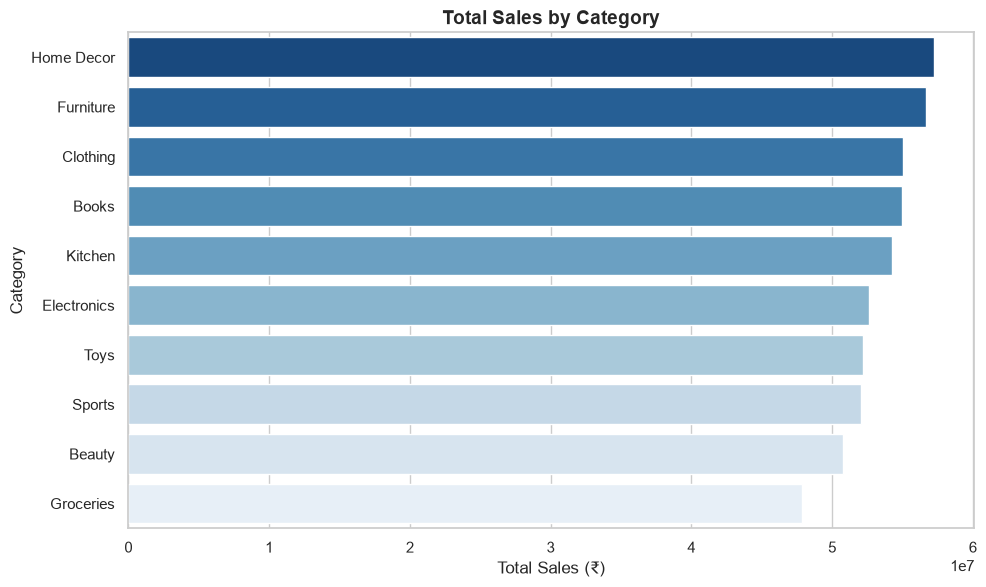

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.values, y=category_sales.index, hue=category_sales.index, palette='Blues_r', legend=False)
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (₹)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [8]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()[:-1]
print(monthly_sales)

Month
2023-10    21307522.20
2023-11    22040269.20
2023-12    20624240.25
2024-01    21477241.40
2024-02    19853396.50
2024-03    21571015.35
2024-04    22214781.10
2024-05    24744786.55
2024-06    21368962.50
2024-07    24019283.90
2024-08    23299894.50
2024-09    22480182.05
2024-10    23607626.65
2024-11    22036247.55
2024-12    24806786.40
2025-01    21520801.80
2025-02    19902446.10
2025-03    22602988.75
2025-04    21653817.90
2025-05    26010928.65
2025-06    21155496.20
2025-07    22526567.55
2025-08    23317916.20
2025-09    18131496.70
Freq: M, Name: Sales, dtype: float64


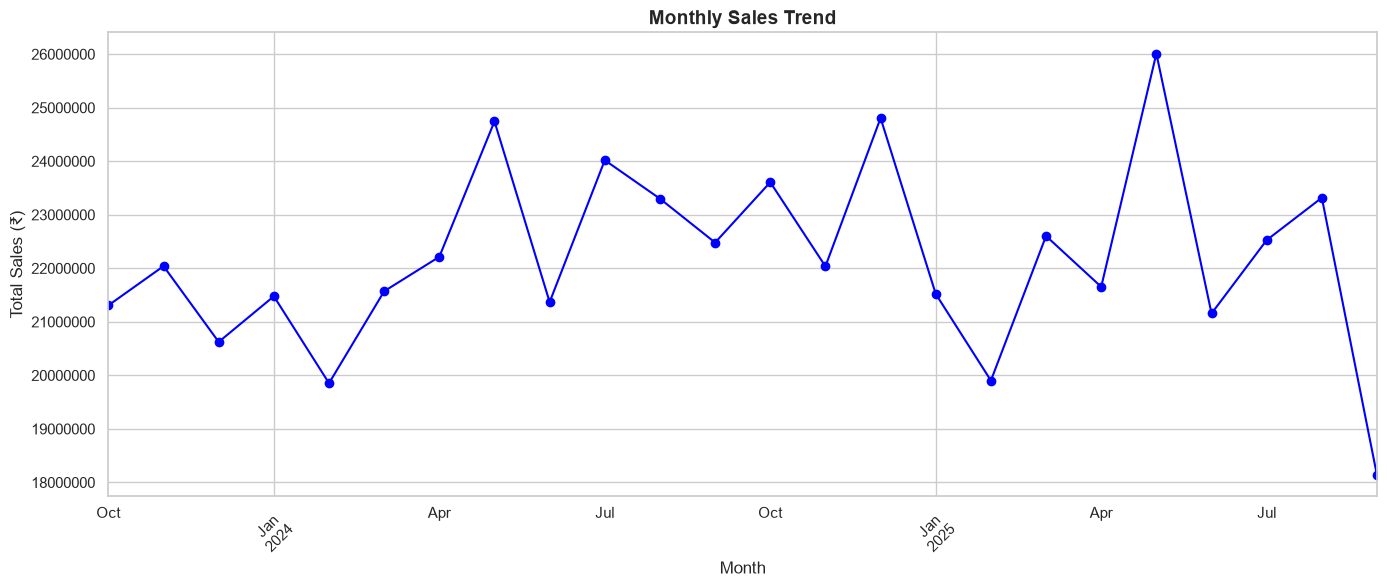

In [9]:
plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

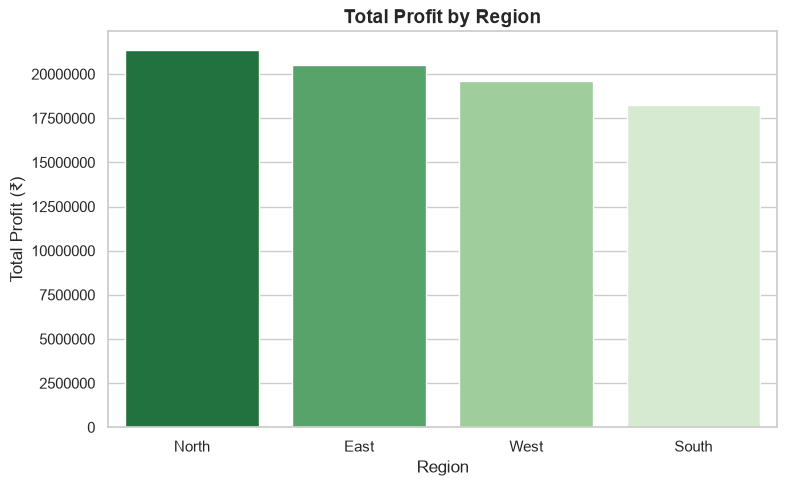

In [10]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index, y=region_profit.values, hue=region_profit.index, palette='Greens_r', legend=False)
plt.title('Total Profit by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit (₹)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

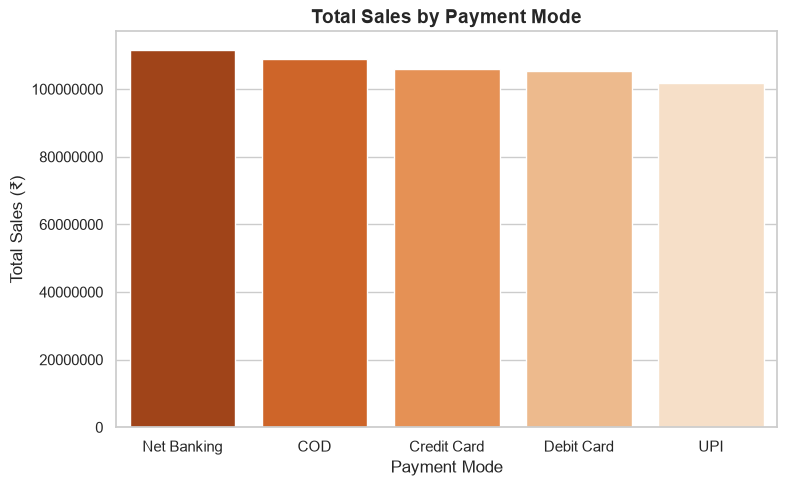

In [11]:
payment_sales = df.groupby('Payment Mode')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=payment_sales.index, y=payment_sales.values, hue=payment_sales.index, palette='Oranges_r', legend=False)
plt.title('Total Sales by Payment Mode', fontsize=14, fontweight='bold')
plt.xlabel('Payment Mode')
plt.ylabel('Total Sales (₹)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

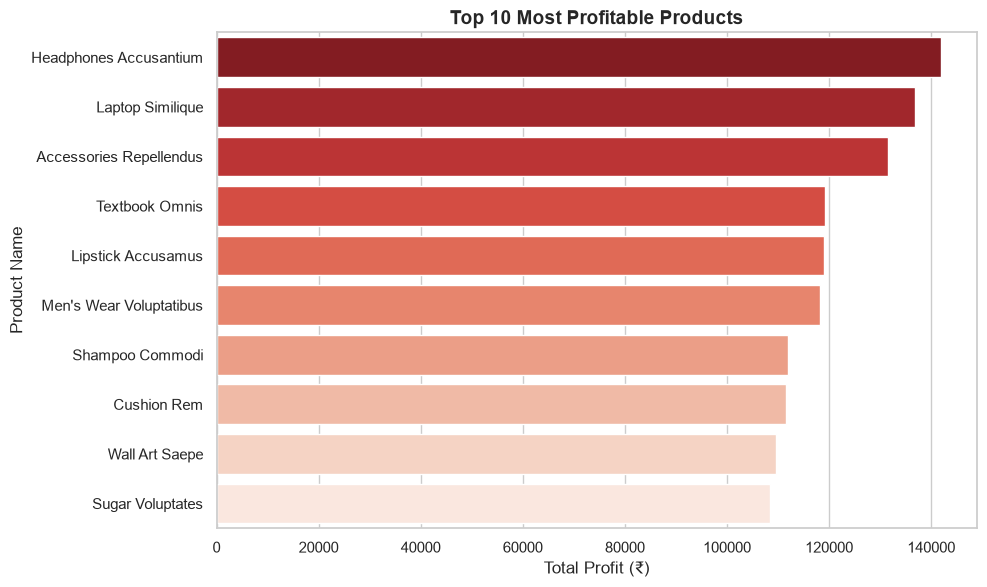

In [12]:
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='Reds_r', legend=False)
plt.title('Top 10 Most Profitable Products', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit (₹)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

## Key Insights

- **Home Decor** is the top selling category
- **May 2025** was the best performing month
- **North Region** generates the highest profit
- **Net Banking** is the most used payment method
- **Headphones Accusantium** is the most profitable product